# Spatial HG — classifier comparison

**Question.** With the high-gamma (70-150 Hz) representation and all 80 channels fixed, do Linear SVM, L2 Logistic Regression, and Shrinkage LDA change the spatial time-resolved decoding conclusion?

| | classifier |
|---|---|
| 1 | Linear SVM (`LinearSVC`, C=0.1, L2) - baseline |
| 2 | L2 multinomial Logistic Regression (`C=0.1`) |
| 3 | Shrinkage LDA (`lsqr`, `shrinkage="auto"`) |

Same preprocessing / CV / channel resampling as the baseline; only the estimator factory changes. Figures: per classifier, Dorsal vs Ventral (1-3); per region, three classifiers overlaid (4-5).

In [1]:
import sys, warnings, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "scripts" / "seeg_io.py").exists() else ROOT.parent
sys.path.insert(0, str(REPO / "scripts"))

from seeg_io import SEEGDataset
from decoding import _svm
from spectral_exp import (
    viable_region_pool, build_hg_tensors, run_condition, viz_smooth, summary_row,
    SPATIAL_CUE_WINDOW, SPATIAL_DELAY_WINDOW,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------------ configuration
TASK         = "spatial"
DATA_FILE    = "Prefrontal_Delay_3_6_sec_Session.mat"
N_CLASSES    = 9
CHANCE       = 1.0 / N_CLASSES
CUE_WINDOW   = SPATIAL_CUE_WINDOW
DELAY_WINDOW = SPATIAL_DELAY_WINDOW

REF          = "Laplacian"
DOWNSAMPLE   = 20
C_SVM        = 0.1
N_CV_REPEATS = 5          # SLOO folds = 3 trials/class × 5 = 15
N_RESAMPLES  = 10
N_CHANNELS   = 80
REGIONS      = ["Dorsal", "Ventral"]
SEED         = 0

ds = SEEGDataset(REPO / "data" / DATA_FILE)
POOLS = {r: viable_region_pool(ds, r, required_classes=N_CLASSES) for r in REGIONS}

print(f"task={TASK}  ref={REF}  downsample={DOWNSAMPLE}  "
      f"N_RESAMPLES={N_RESAMPLES}  N_CHANNELS={N_CHANNELS}  chance={CHANCE:.3f}")
for r in REGIONS:
    print(f"  {r}: {len(POOLS[r])} viable channels")
print(f"windows: cue={CUE_WINDOW}s  delay={DELAY_WINDOW}s  (approximate)")

task=spatial  ref=Laplacian  downsample=20  N_RESAMPLES=10  N_CHANNELS=80  chance=0.111
  Dorsal: 124 viable channels
  Ventral: 78 viable channels
windows: cue=(1.0, 2.0)s  delay=(2.5, 5.5)s  (approximate)


In [2]:
def svm():
    return _svm(C_SVM)

def shrink_lda():
    return make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    )

def logreg():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C_SVM, penalty="l2", solver="lbfgs", max_iter=400),
    )

CLASSIFIERS = {
    "Linear SVM": svm,
    "Shrinkage LDA": shrink_lda,
    "L2 LogReg": logreg,
}

# region colours (figs 1–3); model colours (figs 4–5)
REGION_COL = {"Dorsal": "tab:blue", "Ventral": "tab:red"}
MODEL_COL  = {
    "Linear SVM": "tab:red",
    "Shrinkage LDA": "tab:blue",
    "L2 LogReg": "tab:green",
}

print("classifiers:", list(CLASSIFIERS))

classifiers: ['Linear SVM', 'Shrinkage LDA', 'L2 LogReg']


## Build HG tensors & run three classifiers × two regions

In [3]:
t0 = time.time()
TENSORS = {
    r: build_hg_tensors(
        ds, POOLS[r], n_resamples=N_RESAMPLES, n_channels=N_CHANNELS,
        ref=REF, downsample=DOWNSAMPLE, seed=SEED,
    )
    for r in REGIONS
}
print(f"tensors built in {time.time() - t0:.0f}s  "
      f"X{TENSORS['Dorsal'][0].X.shape}  n_train/fold={TENSORS['Dorsal'][0].X.shape[0] - N_CLASSES}")

RES = {}  # RES[region][classifier]
for region in REGIONS:
    RES[region] = {}
    t1 = time.time()
    for cname, factory in CLASSIFIERS.items():
        # HG-only tensors → band index 0
        RES[region][cname] = run_condition(
            TENSORS[region], [0], factory,
            n_cv_repeats=N_CV_REPEATS,
            cue_window=CUE_WINDOW, delay_window=DELAY_WINDOW, seed=SEED,
        )
    print(f"{region} done in {time.time() - t1:.0f}s")

for region in REGIONS:
    print(f"\n===== {region}  (chance {CHANCE:.3f}) =====")
    for cname in CLASSIFIERS:
        print("  " + summary_row(cname, RES[region][cname]))

tensors built in 122s  X(27, 78, 154)  n_train/fold=18
Dorsal done in 606s
Ventral done in 724s

===== Dorsal  (chance 0.111) =====
  Linear SVM                  p=  78  p/n_train=  4.33  cue=0.113±0.047  delay=0.127±0.047  delayPk=0.235  peak=0.262@2.62s
  Shrinkage LDA               p=  78  p/n_train=  4.33  cue=0.115±0.055  delay=0.096±0.048  delayPk=0.198  peak=0.226@2.34s
  L2 LogReg                   p=  78  p/n_train=  4.33  cue=0.118±0.055  delay=0.119±0.046  delayPk=0.241  peak=0.279@3.18s

===== Ventral  (chance 0.111) =====
  Linear SVM                  p=  78  p/n_train=  4.33  cue=0.110±0.066  delay=0.064±0.031  delayPk=0.190  peak=0.244@1.70s
  Shrinkage LDA               p=  78  p/n_train=  4.33  cue=0.098±0.030  delay=0.086±0.039  delayPk=0.198  peak=0.239@1.39s
  L2 LogReg                   p=  78  p/n_train=  4.33  cue=0.115±0.054  delay=0.069±0.034  delayPk=0.193  peak=0.257@1.10s


## Figures 1–3 — per classifier: Dorsal (blue) vs Ventral (red)

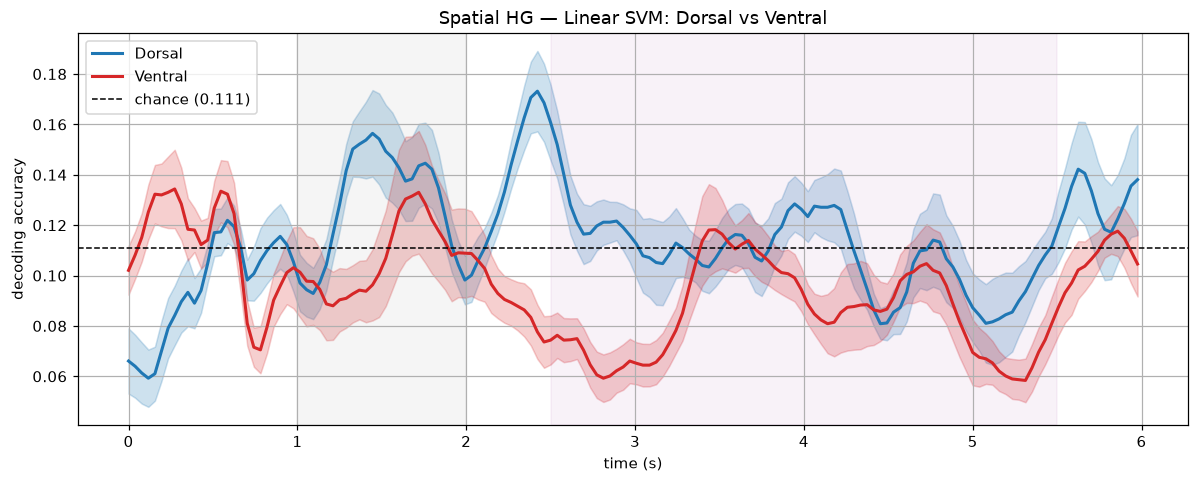

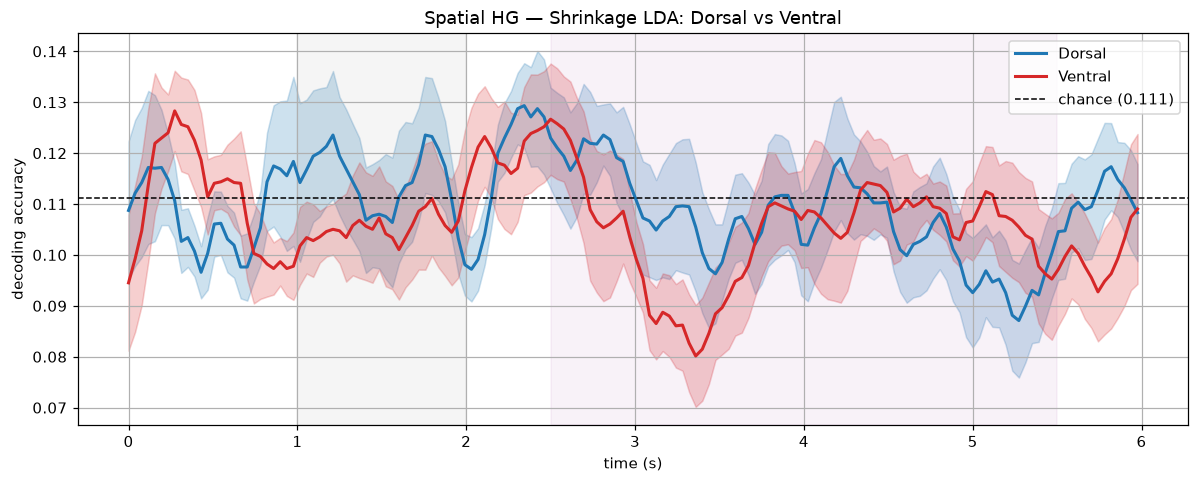

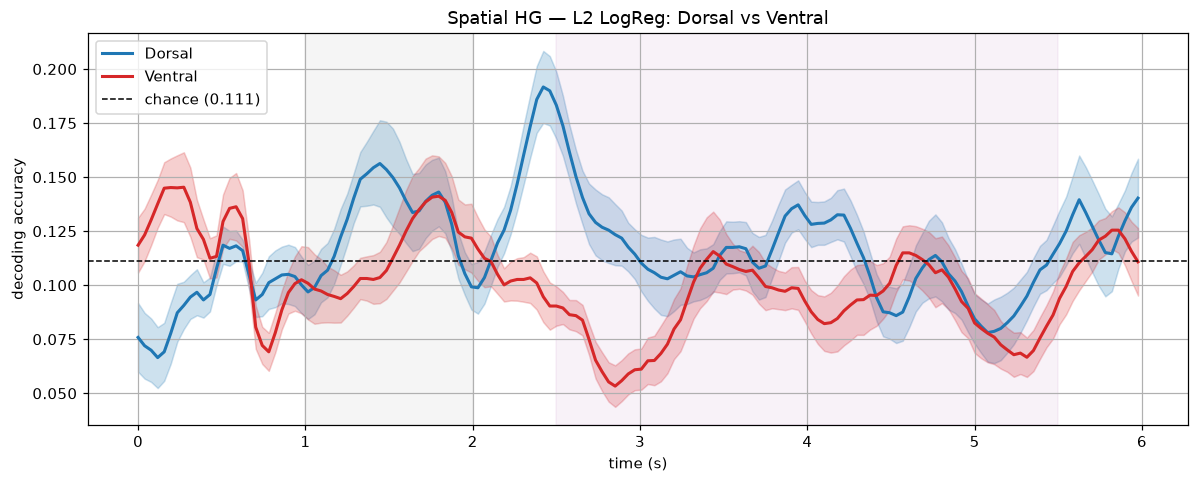

In [4]:
def plot_dorsal_vs_ventral(cname: str):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for region in REGIONS:
        d = RES[region][cname]
        m, se = viz_smooth(d["curves"], 5)
        ax.plot(d["time_s"], m, color=REGION_COL[region], lw=2, label=region)
        ax.fill_between(d["time_s"], m - se, m + se, color=REGION_COL[region], alpha=0.22)
    ax.axhline(CHANCE, color="k", ls="--", lw=1, label=f"chance ({CHANCE:.3f})")
    ax.axvspan(*CUE_WINDOW, color="grey", alpha=0.08)
    ax.axvspan(*DELAY_WINDOW, color="purple", alpha=0.05)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("decoding accuracy")
    ax.set_title(f"Spatial HG — {cname}: Dorsal vs Ventral")
    ax.legend()
    plt.tight_layout()
    plt.show()

for cname in CLASSIFIERS:
    plot_dorsal_vs_ventral(cname)

## Figure 4 — Dorsal: three classifiers
## Figure 5 — Ventral: three classifiers

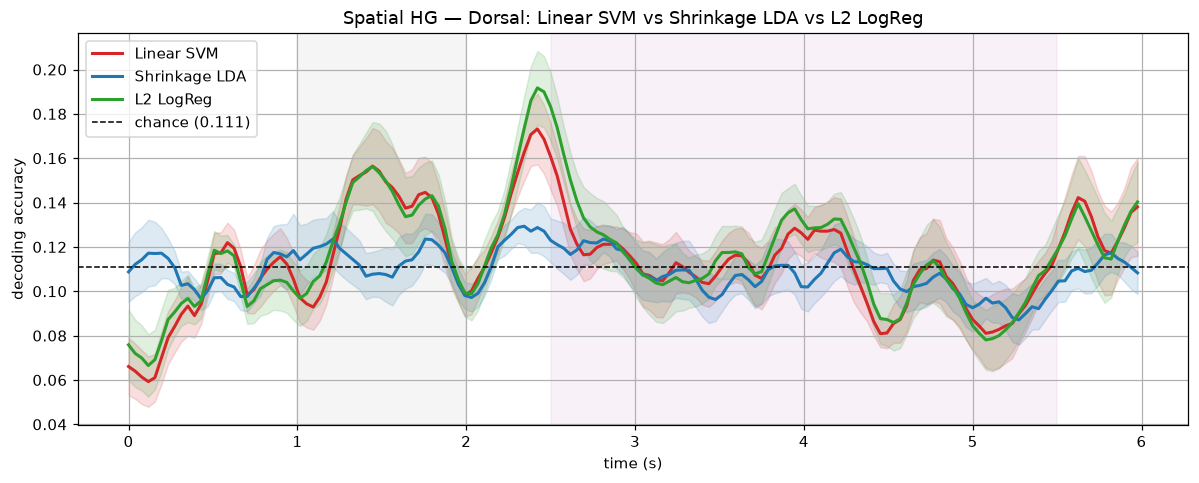

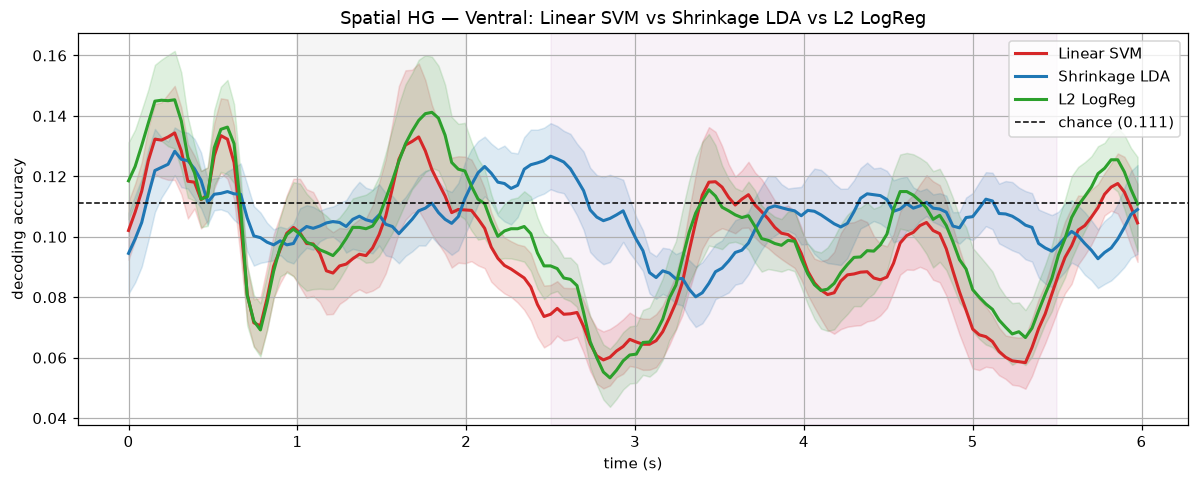

In [5]:
def plot_models_for_region(region: str):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for cname in CLASSIFIERS:
        d = RES[region][cname]
        m, se = viz_smooth(d["curves"], 5)
        ax.plot(d["time_s"], m, color=MODEL_COL[cname], lw=2, label=cname)
        ax.fill_between(d["time_s"], m - se, m + se, color=MODEL_COL[cname], alpha=0.15)
    ax.axhline(CHANCE, color="k", ls="--", lw=1, label=f"chance ({CHANCE:.3f})")
    ax.axvspan(*CUE_WINDOW, color="grey", alpha=0.08)
    ax.axvspan(*DELAY_WINDOW, color="purple", alpha=0.05)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("decoding accuracy")
    ax.set_title(f"Spatial HG — {region}: Linear SVM vs Shrinkage LDA vs L2 LogReg")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_models_for_region("Dorsal")
plot_models_for_region("Ventral")